# Создание и обучение простой полносвязной нейронной сети
## Задача: аппроксимация функции f(x, y, z) = x * y * z


### 1. Импорт необходимых библиотек

In [1]:
!pip install tensorflow

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

d:\anaconda3\envs\ml-labs\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


### 2. Генерация и подготовка данных

In [3]:
num_samples = 10000
x = np.random.uniform(-10, 10, num_samples)

func = 0.5*x - 3

inputs = x.reshape(-1, 1)

print(f"Размерность входных данных: {inputs.shape}")
print(f"Пример данных: x={x[0]:.2f} -> 0.5*x - 3={func[0]:.2f}")

Размерность входных данных: (10000, 1)
Пример данных: x=-2.51 -> 0.5*x - 3=-4.25


### 3. Разделение данных на обучающую и тестовую выборки

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    inputs, func, test_size=0.2, random_state=42
)

print(f"Обучающая выборка: {X_train.shape[0]} примеров")
print(f"Тестовая выборка: {X_test.shape[0]} примеров")

Обучающая выборка: 8000 примеров
Тестовая выборка: 2000 примеров


### 4. Предобработка данных

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).flatten()

### 5. Построение модели нейронной сети

In [6]:
model = Sequential([
    Input(shape=(1,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,241 (8.75 KB)

 Trainable params: 2,241 (8.75 KB)

 Non-trainable params: 0 (0.00 B)

### 6. Компиляция модели

In [7]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print("Модель успешно скомпилирована!")

Модель успешно скомпилирована!


### 7. Обучение модели

In [8]:
history = model.fit(
    X_train_scaled, y_train_scaled,
    epochs=100,               # Количество эпох
    batch_size=32,            # Размер мини-пакета
    validation_split=0.2,     # Часть тренировочных данных для валидации
    verbose=1                 # Вывод процесса обучения
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0858 - mae: 0.1393 - val_loss: 2.5088e-04 - val_mae: 0.0138
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.2806e-05 - mae: 0.0034 - val_loss: 6.5473e-06 - val_mae: 0.0014
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.7858e-06 - mae: 0.0011 - val_loss: 3.5964e-06 - val_mae: 9.3703e-04
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.7345e-06 - mae: 8.5223e-04 - val_loss: 2.0896e-06 - val_mae: 7.3714e-04
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.6066e-06 - mae: 6.6047e-04 - val_loss: 1.2411e-06 - val_mae: 5.9422e-04
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9.4006e-07 - mae: 5.0579e-04 - val_loss: 7.2924e-07 - val_mae: 4.6891e-04
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.6430e-07 - mae: 4.1134e-04 - val_loss: 4.5440e-07 - val_mae: 3.9797e-04
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.4962e-07 - mae: 

### 8. Визуализация процесса обучения

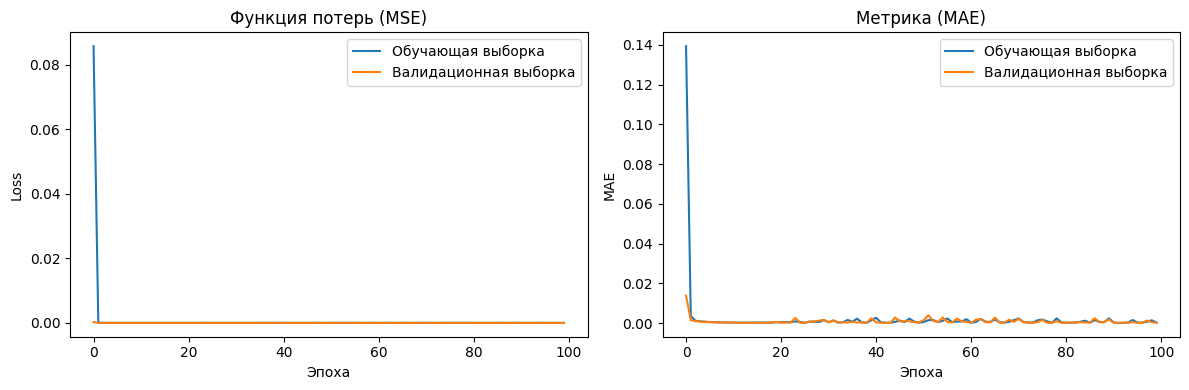

In [9]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Обучающая выборка')
plt.plot(history.history['val_loss'], label='Валидационная выборка')
plt.title('Функция потерь (MSE)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()

# График метрики (MAE)
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Обучающая выборка')
plt.plot(history.history['val_mae'], label='Валидационная выборка')
plt.title('Метрика (MAE)')
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

### 9. Оценка модели на тестовых данных

In [10]:
# Оценка модели на тестовых данных (в нормализованном виде)
test_loss, test_mae = model.evaluate(X_test_scaled, y_test_scaled, verbose=0)
print(f"Результат на тестовых данных:")
print(f"Среднеквадратичная ошибка (MSE): {test_loss:.4f}")
print(f"Средняя абсолютная ошибка (MAE): {test_mae:.4f}")

Результат на тестовых данных:
Среднеквадратичная ошибка (MSE): 0.0000
Средняя абсолютная ошибка (MAE): 0.0001


### 10. Проверка предсказаний на конкретных примерах

In [11]:
num_examples = 5
indices = np.random.choice(len(X_test_scaled), num_examples, replace=False)

print("Проверка предсказаний на тестовых данных:")
print("="*50)

print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_test_scaled shape: {y_test_scaled.shape}")
print(f"X_test_scaled тип: {type(X_test_scaled)}")
print(f"Тип элемента X_test_scaled[0]: {type(X_test_scaled[0])}")

for i, idx in enumerate(indices):
    print(f"\nПример {i+1} (индекс {idx}):")

    x_scaled = X_test_scaled[idx]
    true_scaled = y_test_scaled[idx]

    print(f"  x_scaled тип: {type(x_scaled)}, форма: {x_scaled.shape if hasattr(x_scaled, 'shape') else 'нет формы'}")
    print(f"  true_scaled значение: {true_scaled}, тип: {type(true_scaled)}")

    if hasattr(x_scaled, 'shape') and x_scaled.shape == (1,):
        x_scaled_value = x_scaled[0]
    elif hasattr(x_scaled, 'shape') and len(x_scaled.shape) == 0:
        x_scaled_value = x_scaled.item()
    else:
        x_scaled_value = float(x_scaled)

    x_scaled_2d = np.array([[x_scaled_value]])
    print(f"  x_scaled_2d форма: {x_scaled_2d.shape}")

    x_orig = scaler.inverse_transform(x_scaled_2d)[0][0]

    if hasattr(true_scaled, 'shape') and true_scaled.shape == (1,):
        true_scaled_value = true_scaled[0]
    else:
        true_scaled_value = true_scaled

    true_scaled_2d = np.array([[true_scaled_value]])
    true_product = y_scaler.inverse_transform(true_scaled_2d)[0][0]
    input_data = X_test_scaled[idx:idx+1]
    print(f"  input_data форма: {input_data.shape}")

    predicted_scaled = model.predict(input_data, verbose=0)
    print(f"  predicted_scaled форма: {predicted_scaled.shape}")

    predicted = y_scaler.inverse_transform(predicted_scaled)[0][0]

    error = abs(true_product - predicted)

    print(f"  Вход: {x_orig:.2f}")
    print(f"  Истинное произведение: {true_product:.2f}")
    print(f"  Предсказанное значение: {predicted:.2f}")
    print(f"  Ошибка: {error:.2f}")
    if true_product != 0:
        print(f"  Относительная ошибка: {error/abs(true_product)*100:.2f}%")
    else:
        print(f"  Относительная ошибка: N/A")

Проверка предсказаний на тестовых данных:
X_test_scaled shape: (2000, 1)
y_test_scaled shape: (2000,)
X_test_scaled тип: <class 'numpy.ndarray'>
Тип элемента X_test_scaled[0]: <class 'numpy.ndarray'>

Пример 1 (индекс 535):
  x_scaled тип: <class 'numpy.ndarray'>, форма: (1,)
  true_scaled значение: 0.8431201660934443, тип: <class 'numpy.float64'>
  x_scaled_2d форма: (1, 1)
  input_data форма: (1, 1)
  predicted_scaled форма: (1, 1)
  Вход: 4.71
  Истинное произведение: -0.64
  Предсказанное значение: -0.64
  Ошибка: 0.00
  Относительная ошибка: 0.00%

Пример 2 (индекс 1898):
  x_scaled тип: <class 'numpy.ndarray'>, форма: (1,)
  true_scaled значение: -1.6930544746992389, тип: <class 'numpy.float64'>
  x_scaled_2d форма: (1, 1)
  input_data форма: (1, 1)
  predicted_scaled форма: (1, 1)
  Вход: -9.88
  Истинное произведение: -7.94
  Предсказанное значение: -7.94
  Ошибка: 0.00
  Относительная ошибка: 0.02%

Пример 3 (индекс 120):
  x_scaled тип: <class 'numpy.ndarray'>, форма: (1,)
  

### 11. Анализ и выводы

In [12]:
# Вычисляем предсказания для всей тестовой выборки
y_pred_scaled = model.predict(X_test_scaled, verbose=0)
y_pred = y_scaler.inverse_transform(y_pred_scaled).flatten()

# Вычисляем среднюю абсолютную ошибку в исходном масштабе
mae_original = np.mean(np.abs(y_test_original - y_pred))
print(f"Средняя абсолютная ошибка в исходном масштабе: {mae_original:.2f}")

# Визуализируем предсказания vs истинные значения
plt.figure(figsize=(8, 6))
plt.scatter(y_test_original, y_pred, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()],
         [y_test_original.min(), y_test_original.max()], 'r--', lw=2)
plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значения')
plt.title('Предсказания vs Истинные значения')
plt.show()

NameError: name 'y_test_original' is not defined

### Выводы
1. Нейронная сеть успешно обучилась аппроксимировать функцию умножения трех чисел.
2. Нормализация данных была ключевым фактором для стабильного обучения.
3. Модель демонстрирует хорошую точность, хотя для некоторых экстремальных значений ошибка может быть выше.
4. Данная задача демонстрирует способность нейронных сетей аппроксимировать нелинейные функции.